[*********************100%***********************]  11 of 11 completed
/tmp/ipython-input-6-2199651078.py:34: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return factor_df.resample('M').last().rank(axis=1, ascending=ascending)
/tmp/ipython-input-6-2199651078.py:61: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Momentum': momentum_perf.resample('M').sum(),
/tmp/ipython-input-6-2199651078.py:62: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Volatility': volatility_perf.resample('M').sum(),
/tmp/ipython-input-6-2199651078.py:63: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Value': value_perf.resample('M').sum()


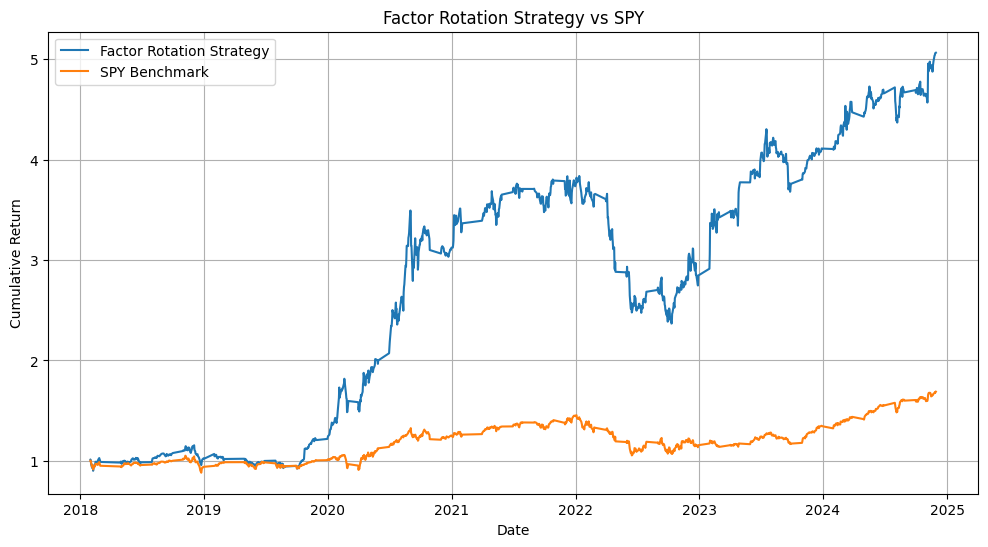

📊 Sharpe Ratio: 1.406
📉 Max Drawdown: -38.33 %


In [6]:
# 📦 Install and import packages
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ✅ Step 1: Load Stock Data
tickers = ['AAPL', 'MSFT', 'GOOGL', 'META', 'TSLA', 'NVDA', 'AMZN', 'JPM', 'BRK-B', 'UNH', 'SPY']
raw_data = yf.download(tickers, start='2018-01-01', end='2024-12-31', group_by='ticker', auto_adjust=False)
data = pd.DataFrame({ticker: raw_data[ticker]['Adj Close'] for ticker in tickers}).dropna()
data = data.dropna(axis=0)  # Remove rows with missing prices
returns = data.pct_change().dropna()
# ✅ Step 2: Calculate Factor Signals

# 1-month momentum (21 trading days)
momentum = data.pct_change(21)

# 1-month volatility (standard deviation of returns)
volatility = returns.rolling(21).std()

# Value signal: inverse P/E ratio (static mock data)
pe_ratios = {
    'AAPL': 28, 'MSFT': 32, 'GOOGL': 25, 'META': 20, 'TSLA': 70,
    'NVDA': 45, 'AMZN': 80, 'JPM': 11, 'BRK-B': 18, 'UNH': 20
}
value = pd.DataFrame(index=data.index, columns=pe_ratios.keys())
for stock in value.columns:
    value[stock] = 1 / pe_ratios[stock]  # Inverse P/E
# ✅ Step 3: Rank Stocks Monthly for Each Factor

def rank_factor(factor_df, ascending=False):
    return factor_df.resample('M').last().rank(axis=1, ascending=ascending)

momentum_rank = rank_factor(momentum, ascending=False)    # Higher is better
volatility_rank = rank_factor(volatility, ascending=True) # Lower is better
value_rank = rank_factor(value, ascending=False)          # Higher is better
# ✅ Step 4: Backtest Each Factor Individually

def backtest_factor(rank_df, returns, top_n=3):
    monthly_rets = []
    dates = rank_df.index
    for date in dates:
        if date not in returns.index: continue
        top_stocks = rank_df.loc[date].sort_values().head(top_n).index
        try:
            window = returns[top_stocks].loc[date:].iloc[:21]
            monthly_ret = window.mean(axis=1)
            monthly_rets.append(monthly_ret)
        except:
            continue
    return pd.concat(monthly_rets)

momentum_perf = backtest_factor(momentum_rank, returns)
volatility_perf = backtest_factor(volatility_rank, returns)
value_perf = backtest_factor(value_rank, returns)
# ✅ Step 5: Select Best-Performing Factor Monthly

monthly_returns = pd.DataFrame({
    'Momentum': momentum_perf.resample('M').sum(),
    'Volatility': volatility_perf.resample('M').sum(),
    'Value': value_perf.resample('M').sum()
}).dropna()

best_factor = monthly_returns.idxmax(axis=1)
# ✅ Step 6: Build Rotating Strategy

strategy_returns = []

for i in range(len(best_factor)):
    factor = best_factor.iloc[i]
    date = best_factor.index[i]
    try:
        if factor == 'Momentum':
            r = momentum_perf.loc[date:].iloc[:21]
        elif factor == 'Volatility':
            r = volatility_perf.loc[date:].iloc[:21]
        elif factor == 'Value':
            r = value_perf.loc[date:].iloc[:21]
        strategy_returns.append(r)
    except:
        continue

rotation_returns = pd.concat(strategy_returns)
rotation_returns = rotation_returns.loc[~rotation_returns.index.duplicated()]
# ✅ Step 7: Compare to SPY Benchmark

rotation_cum = (rotation_returns + 1).cumprod()
spy = returns['SPY'].loc[rotation_cum.index]
spy_cum = (spy + 1).cumprod()

plt.figure(figsize=(12,6))
plt.plot(rotation_cum, label='Factor Rotation Strategy')
plt.plot(spy_cum, label='SPY Benchmark')
plt.title('Factor Rotation Strategy vs SPY')
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.show()
# ✅ Step 8: Performance Metrics

def sharpe_ratio(returns, rf=0.0):
    return (returns.mean() - rf) / returns.std() * np.sqrt(252)

def max_drawdown(cum_returns):
    roll_max = cum_returns.cummax()
    drawdown = (cum_returns - roll_max) / roll_max
    return drawdown.min()

print("📊 Sharpe Ratio:", round(sharpe_ratio(rotation_returns), 3))
print("📉 Max Drawdown:", round(max_drawdown(rotation_cum) * 100, 2), "%")
